/tmp/ipykernel_551165/1233151708.py:21: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, comment='/')
/tmp/ipykernel_551165/1233151708.py:21: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, comment='/')
/tmp/ipykernel_551165/1233151708.py:21: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, comment='/')
/tmp/ipykernel_551165/1233151708.py:59: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_551165/1233151708.py:59: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts

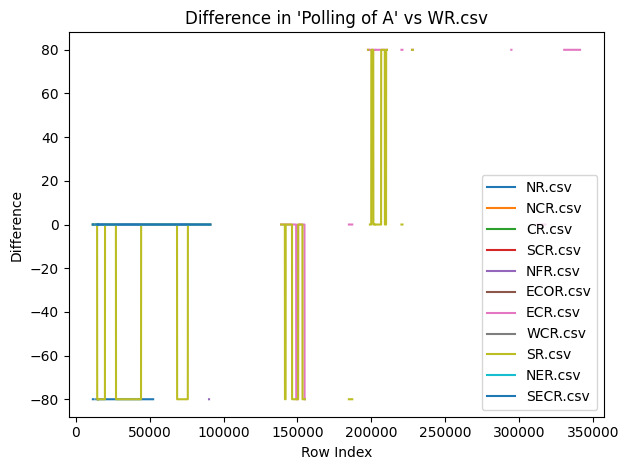

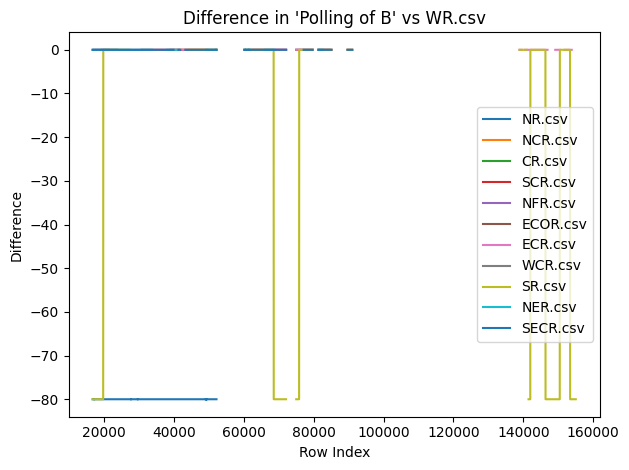

In [3]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Directory containing CSV files
data_dir = "/home/understressengineer/programming/SRM_PS1/FEB 2025 Prototype data"

# Get list of CSV files
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
if not csv_files:
    print("No CSV files found in:", data_dir)
    exit()

# Read the CSV files into a dictionary.
# We assume that lines starting with '//' are comments.
data = {}
for f in csv_files:
    # The parameter comment='/' tells pd.read_csv to skip lines that start with '/'
    df = pd.read_csv(f, comment='/')
    # Use the file basename as key (e.g. SCR.csv, etc.)
    data[os.path.basename(f)] = df

# Find common numeric columns among the dataframes
common_cols = None
for df in data.values():
    num_cols = df.select_dtypes(include=[np.number]).columns
    if common_cols is None:
        common_cols = set(num_cols)
    else:
        common_cols = common_cols.intersection(set(num_cols))
common_cols = list(common_cols)

if not common_cols:
    print("No common numeric columns found among the CSV files.")
    exit()

# Use the first file as the base and calculate row-by-row differences for every other file.
file_names = list(data.keys())
base_df = data[file_names[0]][common_cols].reset_index(drop=True)

# Compute differences for each file (difference = current file - base file)
differences = {}
for fname in file_names[1:]:
    df = data[fname][common_cols].reset_index(drop=True)
    diff_df = df - base_df
    differences[fname] = diff_df

# Plot the differences for each common column.
for col in common_cols:
    plt.figure()
    for fname, diff_df in differences.items():
        plt.plot(diff_df.index, diff_df[col], label=fname)
    plt.title(f"Difference in '{col}' vs {file_names[0]}")
    plt.xlabel("Row Index")
    plt.ylabel("Difference")
    plt.legend()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_551165/3529215697.py:24: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, comment='/')
/tmp/ipykernel_551165/3529215697.py:24: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, comment='/')
/tmp/ipykernel_551165/3529215697.py:24: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, comment='/')
/tmp/ipykernel_551165/3529215697.py:69: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_551165/3529215697.py:69: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts

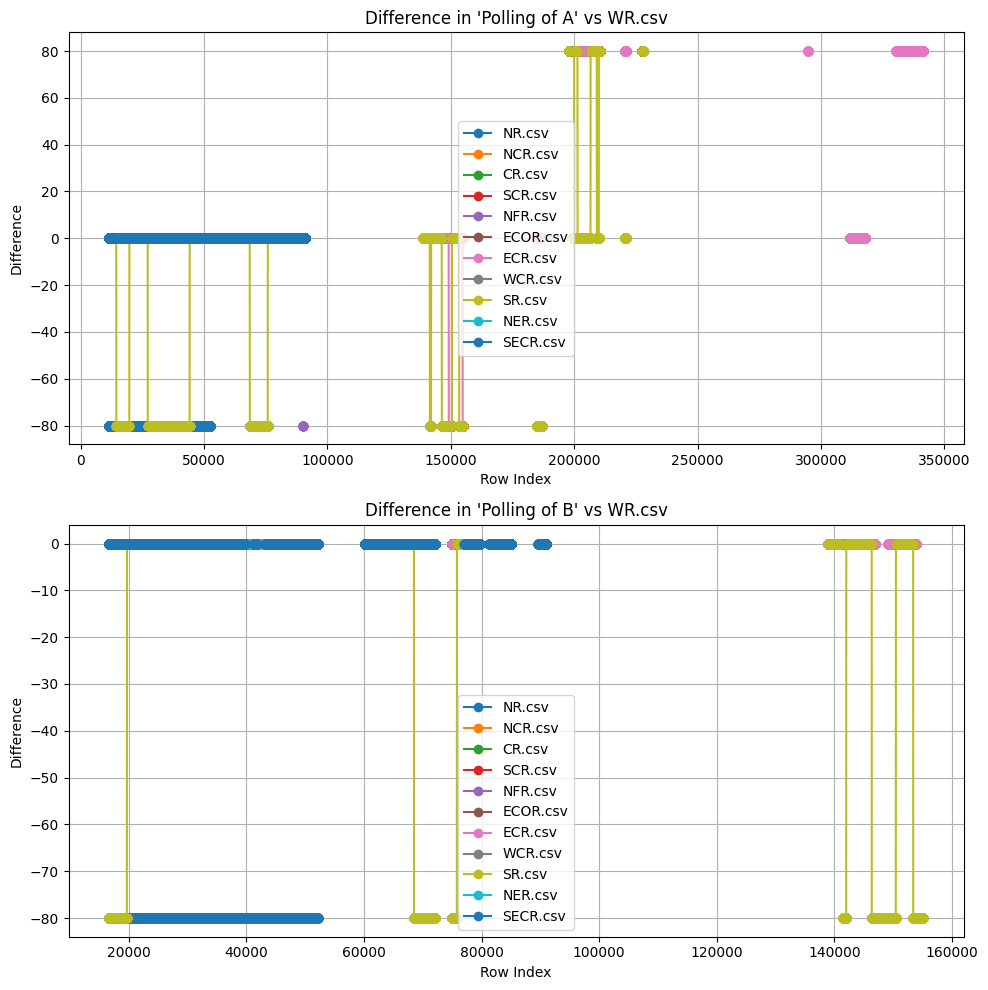

In [4]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use a clean and modern style for plots.
# plt.style.use('seaborn-darkgrid')

# Directory containing CSV files
data_dir = "/home/understressengineer/programming/SRM_PS1/FEB 2025 Prototype data"

# Get list of CSV files
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
if not csv_files:
    print("No CSV files found in:", data_dir)
    exit()

# Read the CSV files into a dictionary.
# We assume that lines starting with '//' are comments.
data = {}
for f in csv_files:
    try:
        df = pd.read_csv(f, comment='/')
        data[os.path.basename(f)] = df
    except Exception as e:
        print(f"Error reading {f}: {e}")

# Find common numeric columns among the dataframes
common_cols = None
for df in data.values():
    num_cols = df.select_dtypes(include=[np.number]).columns
    if common_cols is None:
        common_cols = set(num_cols)
    else:
        common_cols = common_cols.intersection(set(num_cols))
common_cols = sorted(list(common_cols))  # sort for consistency

if not common_cols:
    print("No common numeric columns found among the CSV files.")
    exit()

# Use the first file as the base and calculate differences for every other file.
file_names = list(data.keys())
base_df = data[file_names[0]][common_cols].reset_index(drop=True)

# Compute differences for each file (difference = current file - base file)
differences = {}
for fname in file_names[1:]:
    df = data[fname][common_cols].reset_index(drop=True)
    diff_df = df - base_df
    differences[fname] = diff_df

# Create subplots: one plot per common column.
num_plots = len(common_cols)
fig, axes = plt.subplots(num_plots, 1, figsize=(10, 5 * num_plots))
if num_plots == 1:
    axes = [axes]

for ax, col in zip(axes, common_cols):
    for fname, diff_df in differences.items():
        ax.plot(diff_df.index, diff_df[col], marker='o', linestyle='-', label=fname)
    ax.set_title(f"Difference in '{col}' vs {file_names[0]}")
    ax.set_xlabel("Row Index")
    ax.set_ylabel("Difference")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [4]:
!pip install seaborn

     ▄▀▀▄     
    ▄▀▀▀▀▀▄   
    ▀▀▀▀▀▀    
  ▄▄▀▀▀▀▄     
▄▀▀▀▀▀▀▀▀▀▄   
▀▀▀▀▀▀▀▀▀▀▀   
▀▀▀▀▀▀▀▀▀▀▀   
 ▄▀▀▀▀▀▀▀  ▄▄ 
 ▄▀▀▀▀▀▀▀▀▀▀▀▀
  ▀▀▀▀▀▀▀▀▀▀▀ 
      ▀▀▀▀    


/tmp/ipykernel_551165/2365637505.py:25: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, comment='/')
/tmp/ipykernel_551165/2365637505.py:25: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, comment='/')
/tmp/ipykernel_551165/2365637505.py:25: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, comment='/')
/tmp/ipykernel_551165/2365637505.py:70: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_551165/2365637505.py:70: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts

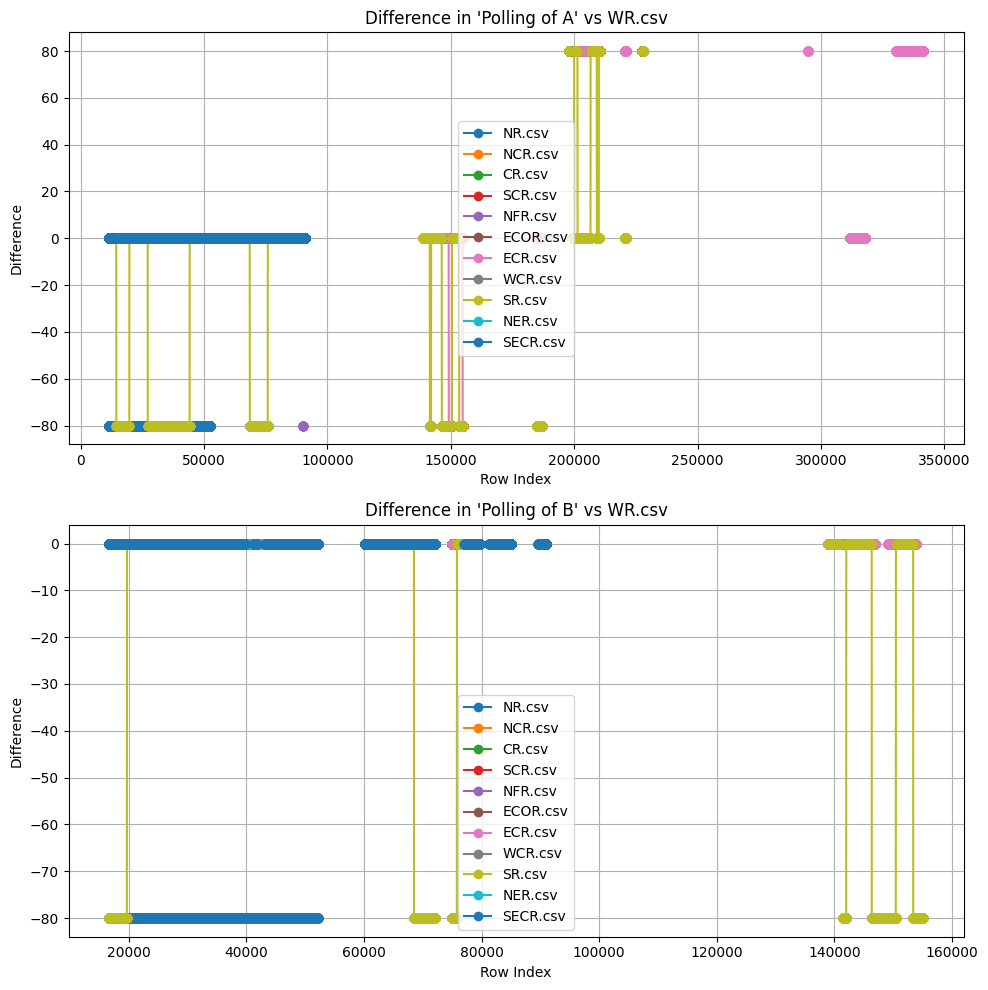

In [5]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use a clean and modern style for plots.
# plt.style.use('seaborn-darkgrid')  # Correct spelling

# Directory containing CSV files
data_dir = "/home/understressengineer/programming/SRM_PS1/FEB 2025 Prototype data"

# Get list of CSV files
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
if not csv_files:
    print("No CSV files found in:", data_dir)
    exit()

# Read the CSV files into a dictionary.
# We assume that lines starting with '//' are comments.
data = {}
for f in csv_files:
    try:
        # Skip lines starting with '/' (comments)
        df = pd.read_csv(f, comment='/')
        data[os.path.basename(f)] = df
    except Exception as e:
        print(f"Error reading {f}: {e}")

# Find common numeric columns among the dataframes
common_cols = None
for df in data.values():
    num_cols = df.select_dtypes(include=[np.number]).columns
    if common_cols is None:
        common_cols = set(num_cols)
    else:
        common_cols = common_cols.intersection(set(num_cols))
common_cols = sorted(list(common_cols))  # sort for consistency

if not common_cols:
    print("No common numeric columns found among the CSV files.")
    exit()

# Use the first file as the base and calculate differences for every other file.
file_names = list(data.keys())
base_df = data[file_names[0]][common_cols].reset_index(drop=True)

# Compute differences for each file (difference = current file - base file)
differences = {}
for fname in file_names[1:]:
    df = data[fname][common_cols].reset_index(drop=True)
    diff_df = df - base_df
    differences[fname] = diff_df

# Create subplots: one plot per common column.
num_plots = len(common_cols)
fig, axes = plt.subplots(num_plots, 1, figsize=(10, 5 * num_plots))
if num_plots == 1:
    axes = [axes]

for ax, col in zip(axes, common_cols):
    for fname, diff_df in differences.items():
        ax.plot(diff_df.index, diff_df[col], marker='o', linestyle='-', label=fname)
    ax.set_title(f"Difference in '{col}' vs {file_names[0]}")
    ax.set_xlabel("Row Index")
    ax.set_ylabel("Difference")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_219016/1273942413.py:24: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, comment='/')
/tmp/ipykernel_219016/1273942413.py:24: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, comment='/')
/tmp/ipykernel_219016/1273942413.py:24: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, comment='/')
/tmp/ipykernel_219016/1273942413.py:63: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_219016/1273942413.py:63: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts

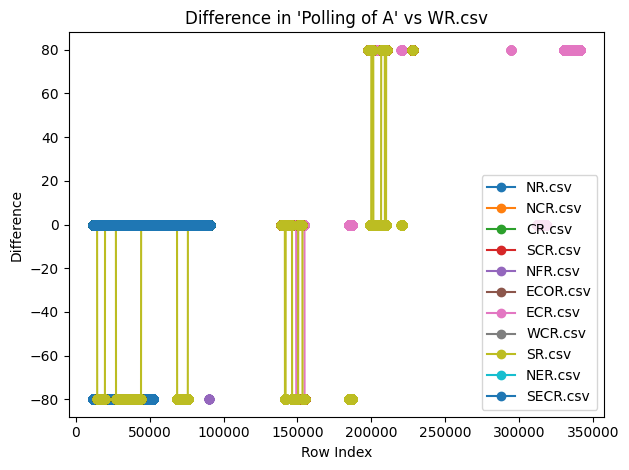

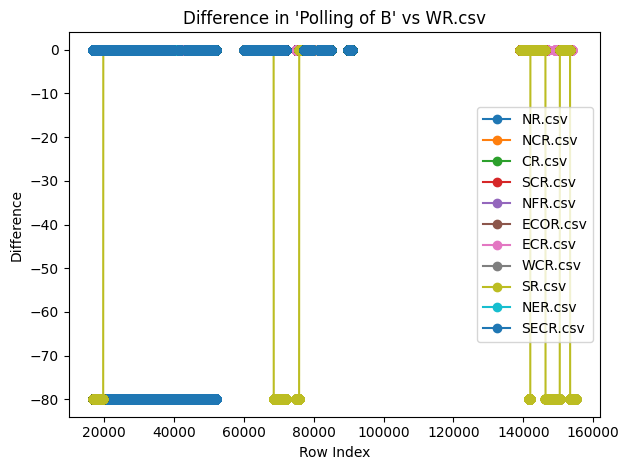

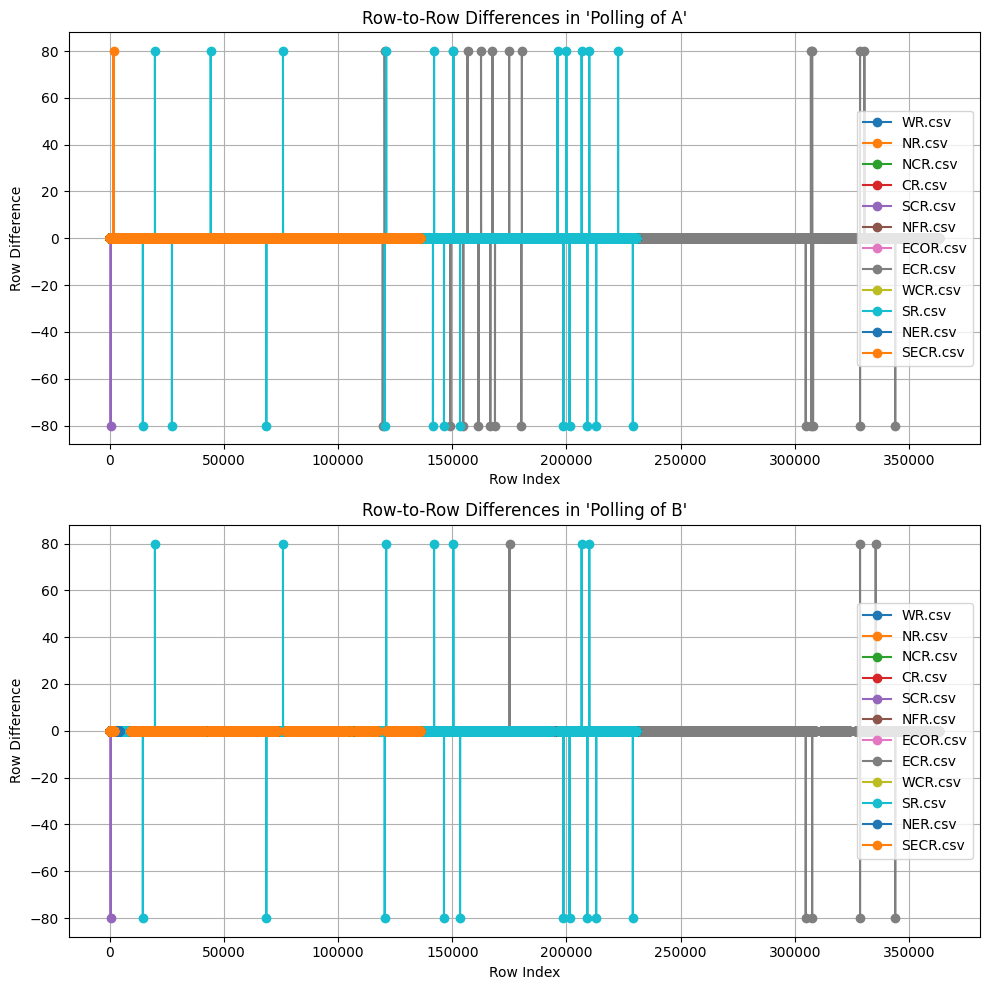

In [9]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use a clean and modern style for plots.
# plt.style.use('seaborn-darkgrid')

# Directory containing CSV files
data_dir = "/home/understressengineer/programming/SRM_PS1/FEB 2025 Prototype data"

# Get list of CSV files
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
if not csv_files:
    print("No CSV files found in:", data_dir)
    exit()

# Read the CSV files into a dictionary.
# We assume that lines starting with '//' are comments.
data = {}
for f in csv_files:
    try:
        df = pd.read_csv(f, comment='/')
        data[os.path.basename(f)] = df
    except Exception as e:
        print(f"Error reading {f}: {e}")

# Find common numeric columns among the dataframes
common_cols = None
for df in data.values():
    num_cols = df.select_dtypes(include=[np.number]).columns
    if common_cols is None:
        common_cols = set(num_cols)
    else:
        common_cols = common_cols.intersection(set(num_cols))
common_cols = sorted(list(common_cols))  # sort for consistency

if not common_cols:
    print("No common numeric columns found among the CSV files.")
    exit()

# ----- Compute differences between files (using first file as base) -----
file_names = list(data.keys())
base_df = data[file_names[0]][common_cols].reset_index(drop=True)

# Compute differences for each file (difference = current file - base file)
differences = {}
for fname in file_names[1:]:
    df = data[fname][common_cols].reset_index(drop=True)
    diff_df = df - base_df
    differences[fname] = diff_df

# Plot differences between files per common column.
for col in common_cols:
    plt.figure()
    for fname, diff_df in differences.items():
        plt.plot(diff_df.index, diff_df[col], marker='o', linestyle='-', label=fname)
    plt.title(f"Difference in '{col}' vs {file_names[0]}")
    plt.xlabel("Row Index")
    plt.ylabel("Difference")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ----- Also compute the row-by-row differences within each file -----
row_differences = {}
for fname, df in data.items():
    # Using diff() to compute the difference between each row and its preceding row.
    df_rdiff = df[common_cols].diff().reset_index(drop=True)
    row_differences[fname] = df_rdiff

# Create subplots for row differences (one subplot per common column).
num_plots = len(common_cols)
fig, axes = plt.subplots(num_plots, 1, figsize=(10, 5 * num_plots))
if num_plots == 1:
    axes = [axes]

for ax, col in zip(axes, common_cols):
    for fname, rdiff_df in row_differences.items():
        ax.plot(rdiff_df.index, rdiff_df[col], marker='o', linestyle='-', label=fname)
    ax.set_title(f"Row-to-Row Differences in '{col}'")
    ax.set_xlabel("Row Index")
    ax.set_ylabel("Row Difference")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_219016/1814727145.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_219016/1814727145.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


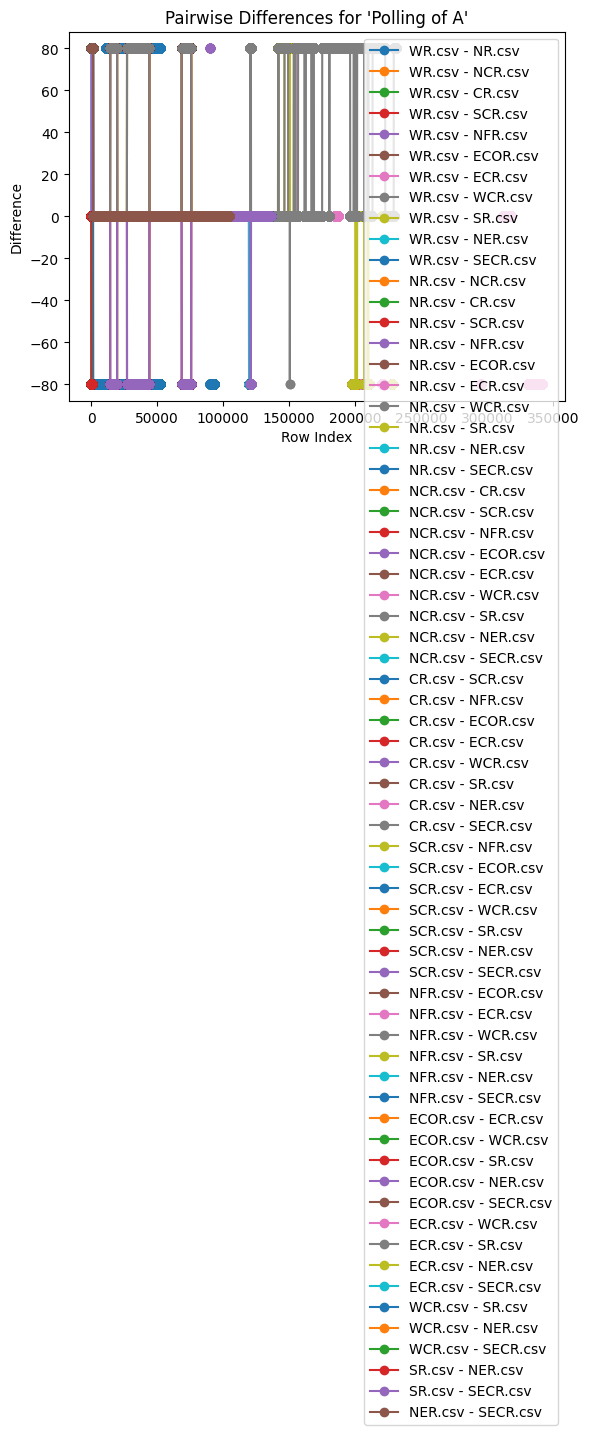

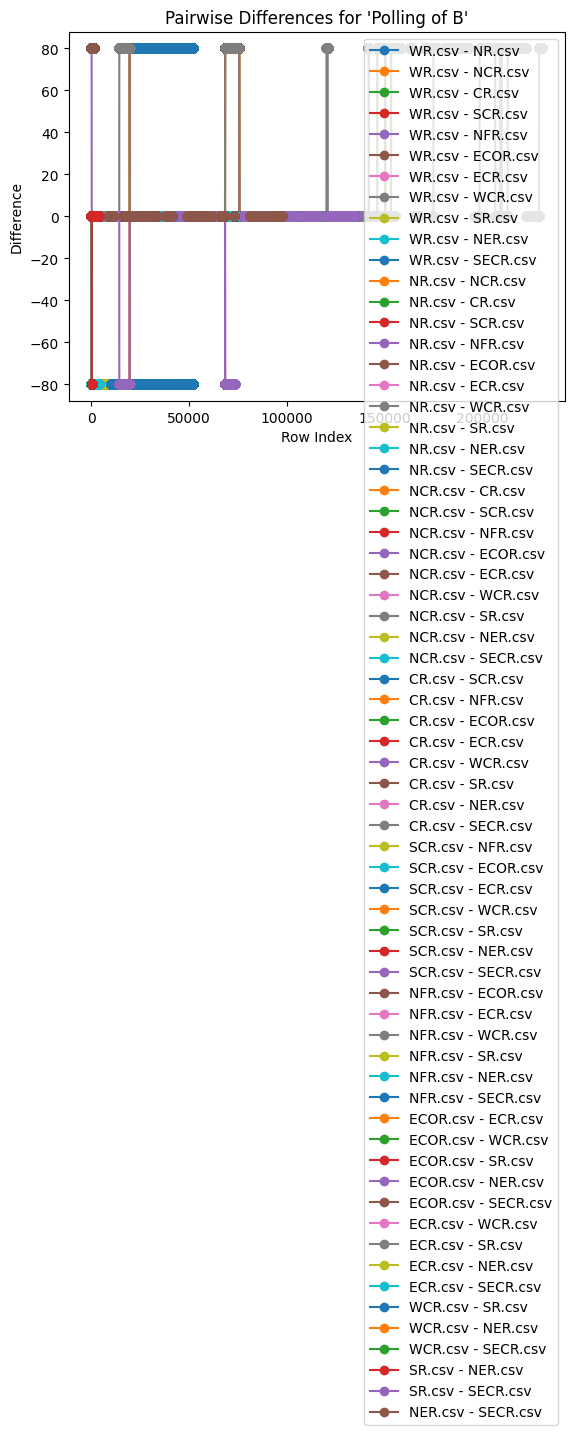

In [10]:
import itertools

# Compute pairwise differences for every combination of CSV files
pairwise_diff = {}
for f1, f2 in itertools.combinations(file_names, 2):
    df1 = data[f1][common_cols].reset_index(drop=True)
    df2 = data[f2][common_cols].reset_index(drop=True)
    pairwise_diff[(f1, f2)] = df1 - df2

# Plot pairwise differences for each common column
for col in common_cols:
    plt.figure()
    for (f1, f2), diff_df in pairwise_diff.items():
        plt.plot(diff_df.index, diff_df[col], marker='o', linestyle='-', label=f"{f1} - {f2}")
    plt.title(f"Pairwise Differences for '{col}'")
    plt.xlabel("Row Index")
    plt.ylabel("Difference")
    plt.legend()
    plt.tight_layout()
    plt.show()

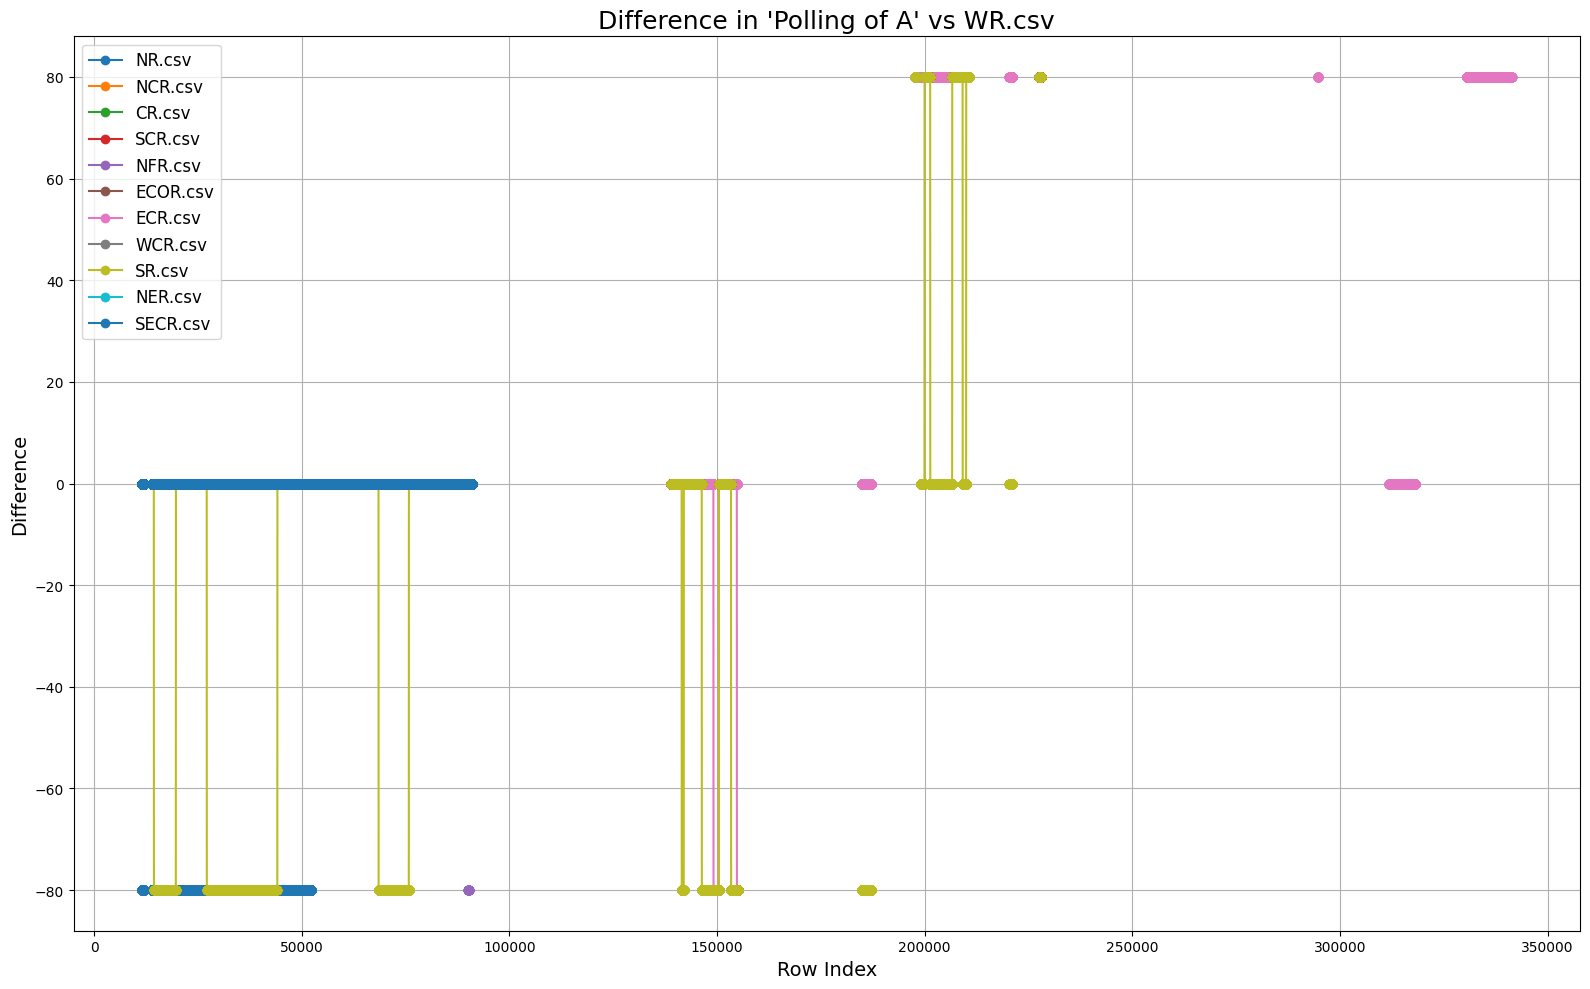

/tmp/ipykernel_219016/718447018.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


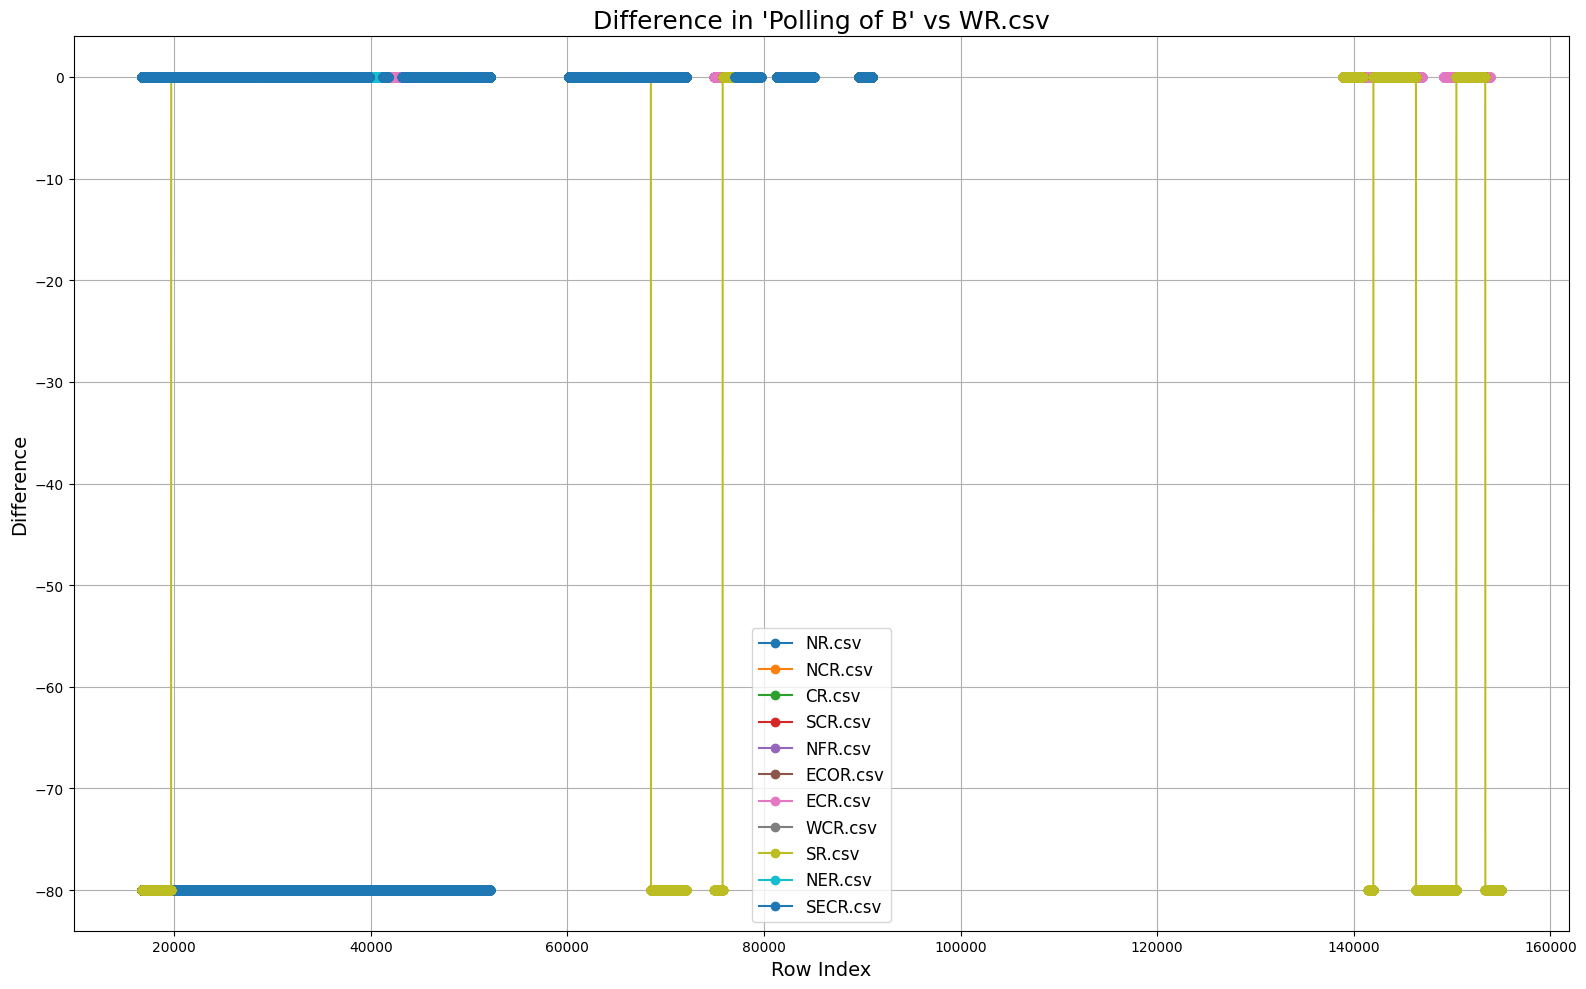

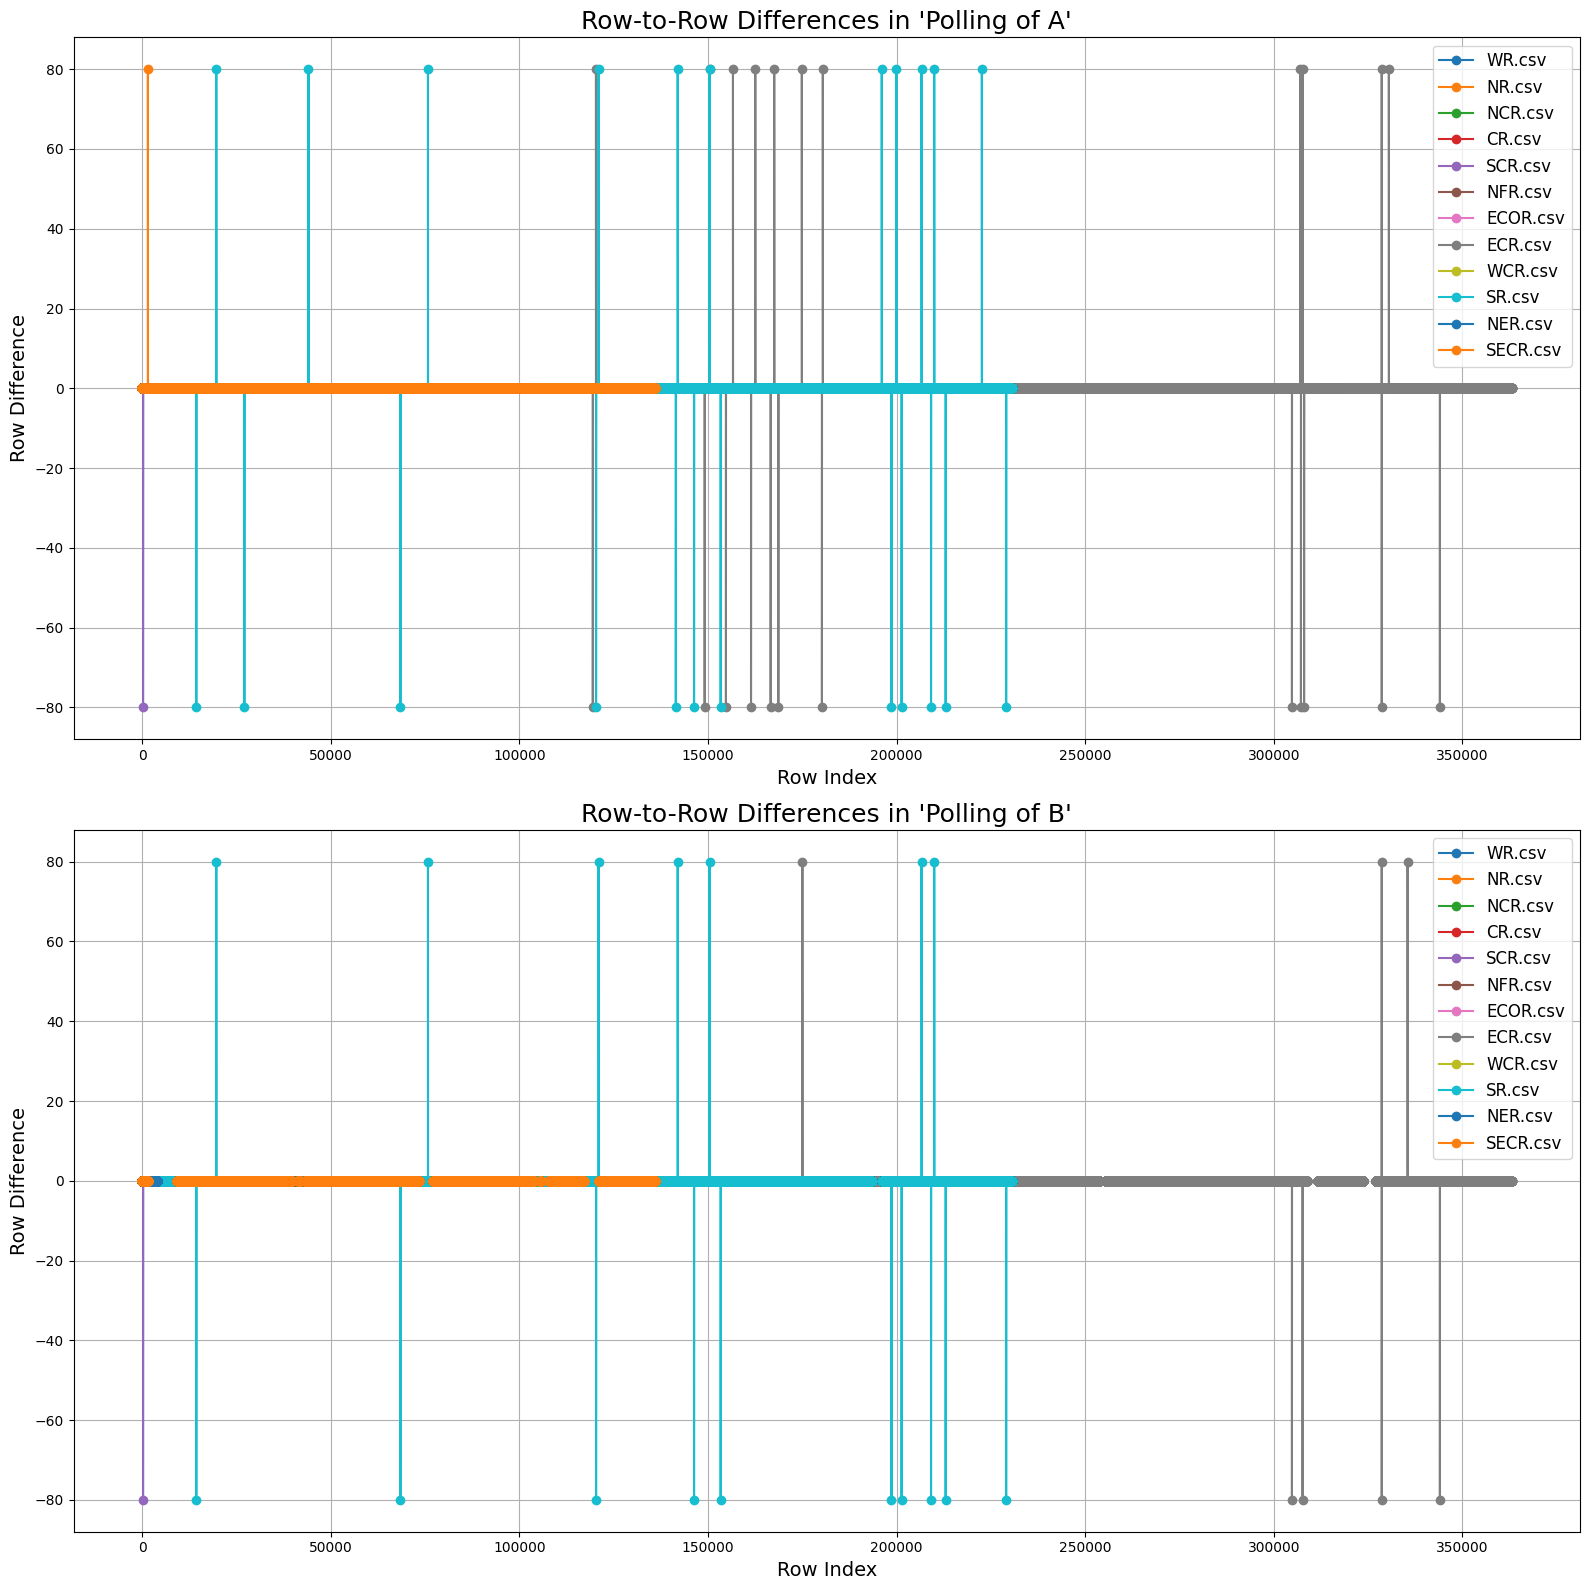

In [11]:
# Plot the differences for each common column with larger figure size
for col in common_cols:
    plt.figure(figsize=(16, 10))  # Increase the figure size
    for fname, diff_df in differences.items():
        plt.plot(diff_df.index, diff_df[col], marker='o', linestyle='-', label=fname)
    plt.title(f"Difference in '{col}' vs {file_names[0]}", fontsize=18)  # Larger title font
    plt.xlabel("Row Index", fontsize=14)  # Larger x-axis label font
    plt.ylabel("Difference", fontsize=14)  # Larger y-axis label font
    plt.legend(fontsize=12)  # Larger legend font
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Create subplots for row differences with larger figure size
num_plots = len(common_cols)
fig, axes = plt.subplots(num_plots, 1, figsize=(16, 8 * num_plots))  # Increase figure size
if num_plots == 1:
    axes = [axes]

for ax, col in zip(axes, common_cols):
    for fname, rdiff_df in row_differences.items():
        ax.plot(rdiff_df.index, rdiff_df[col], marker='o', linestyle='-', label=fname)
    ax.set_title(f"Row-to-Row Differences in '{col}'", fontsize=18)  # Larger title font
    ax.set_xlabel("Row Index", fontsize=14)  # Larger x-axis label font
    ax.set_ylabel("Row Difference", fontsize=14)  # Larger y-axis label font
    ax.legend(fontsize=12)  # Larger legend font
    ax.grid(True)

plt.tight_layout()
plt.show()

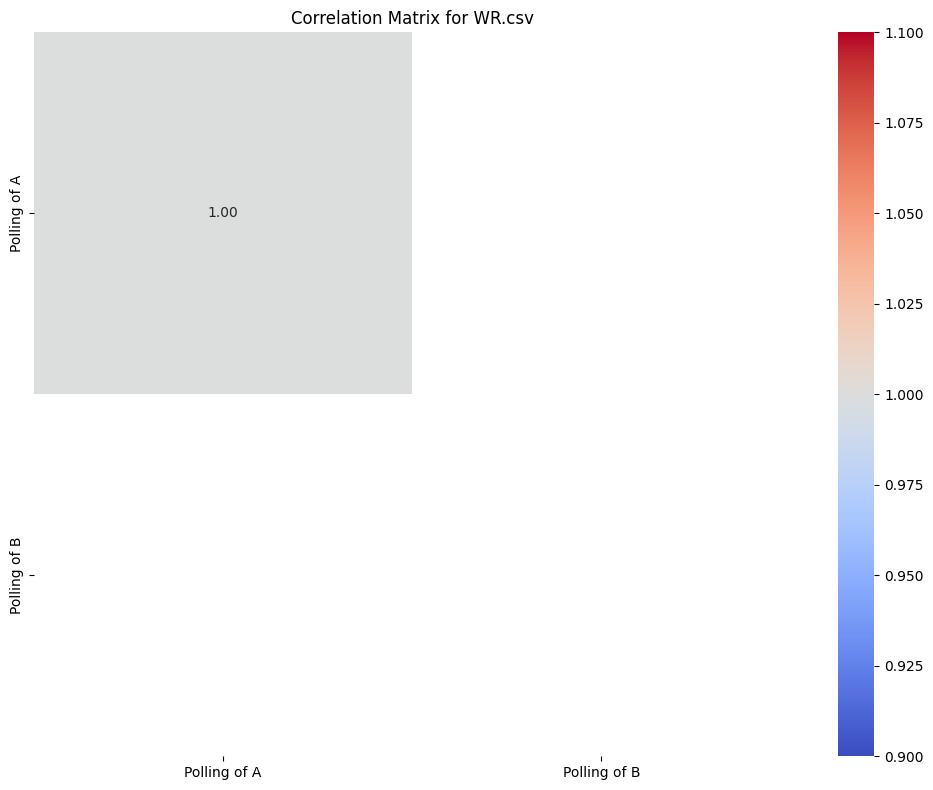

/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


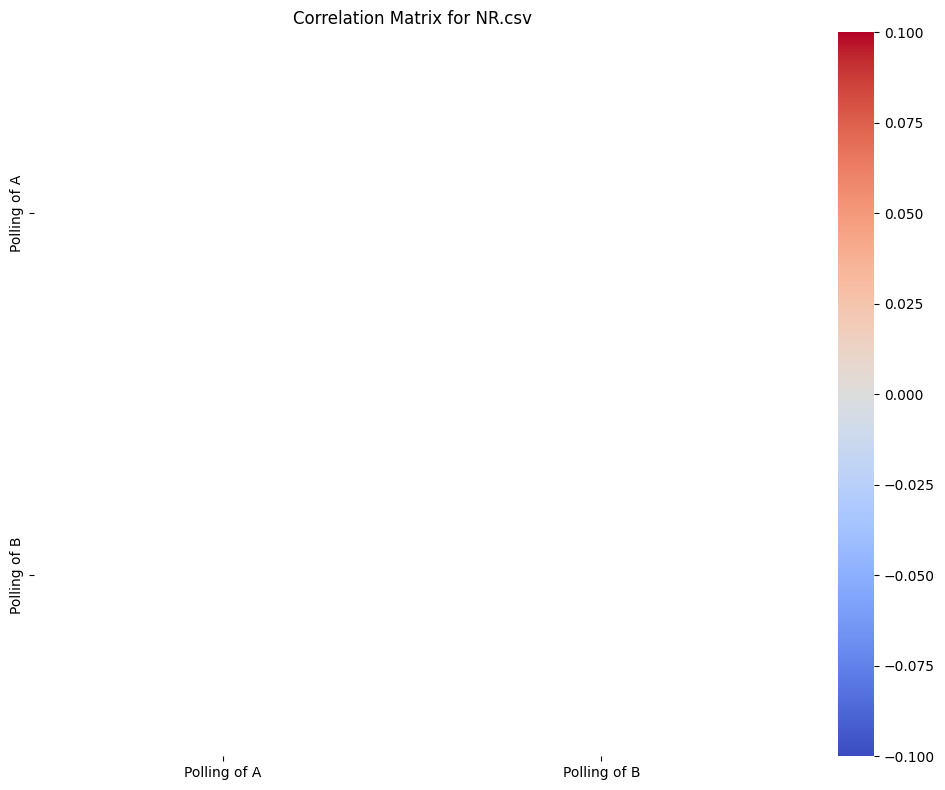

/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


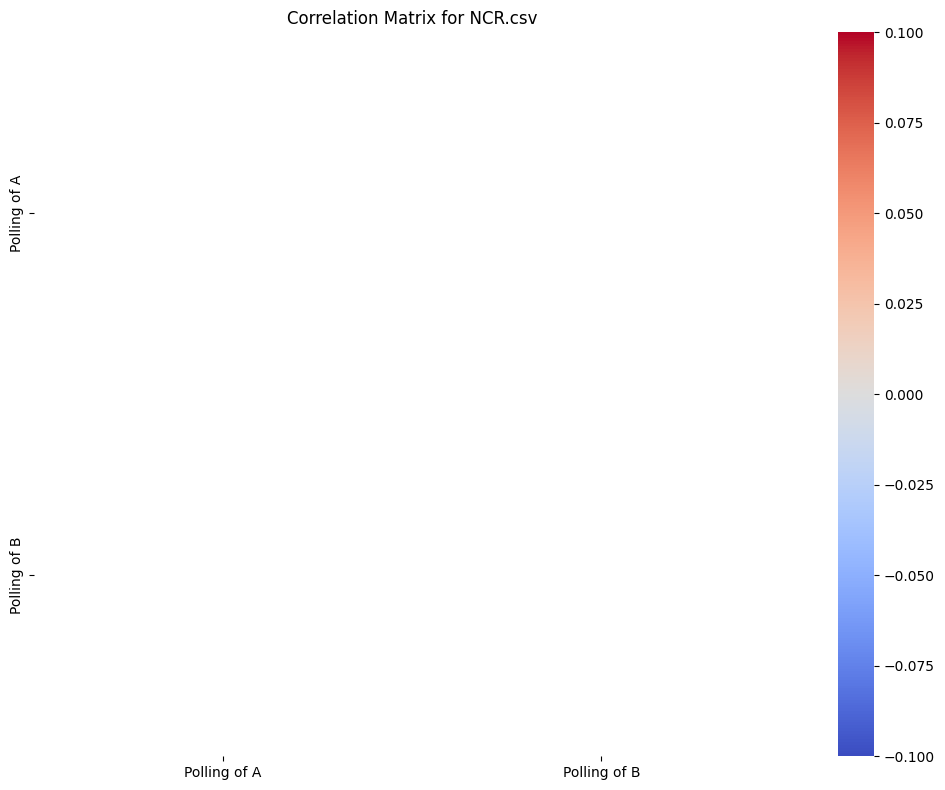

/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


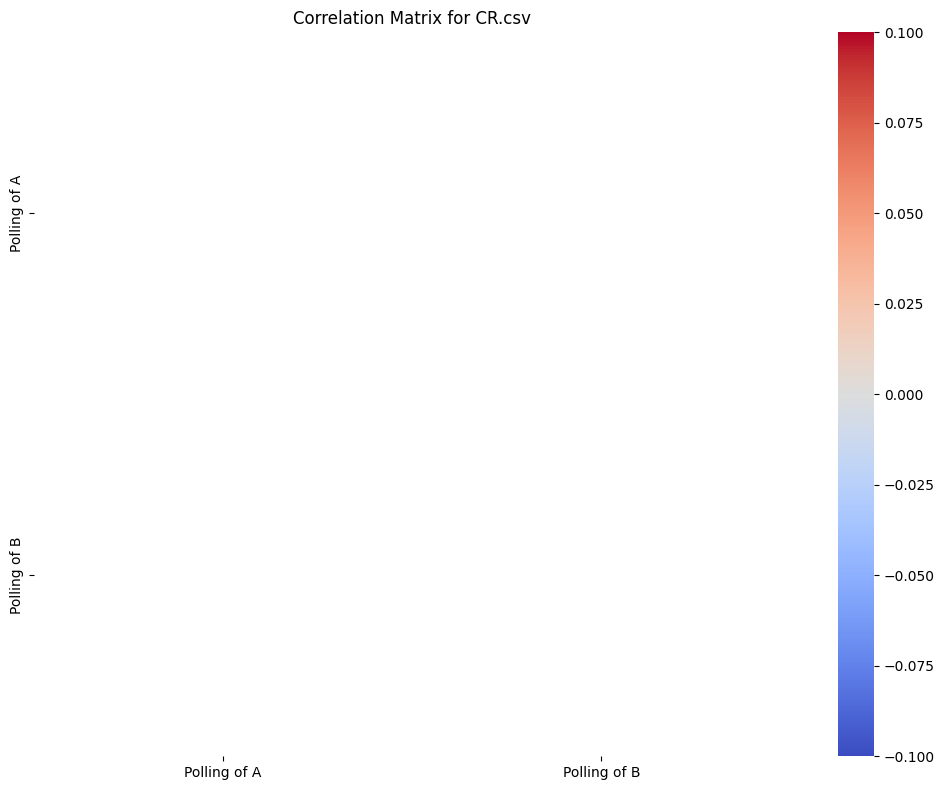

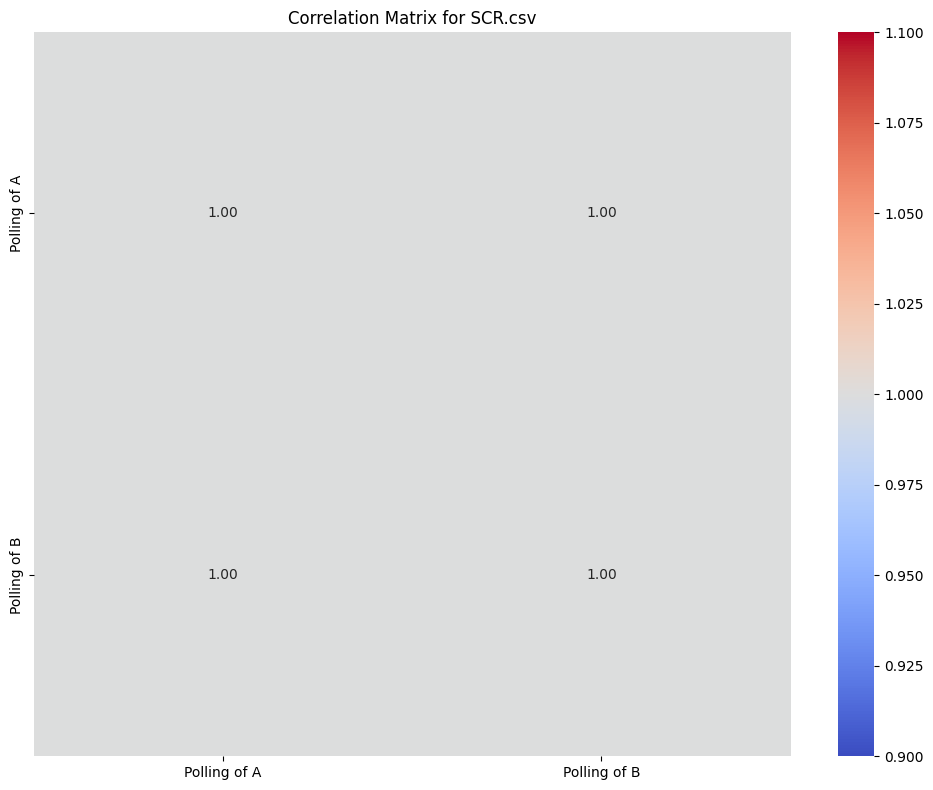

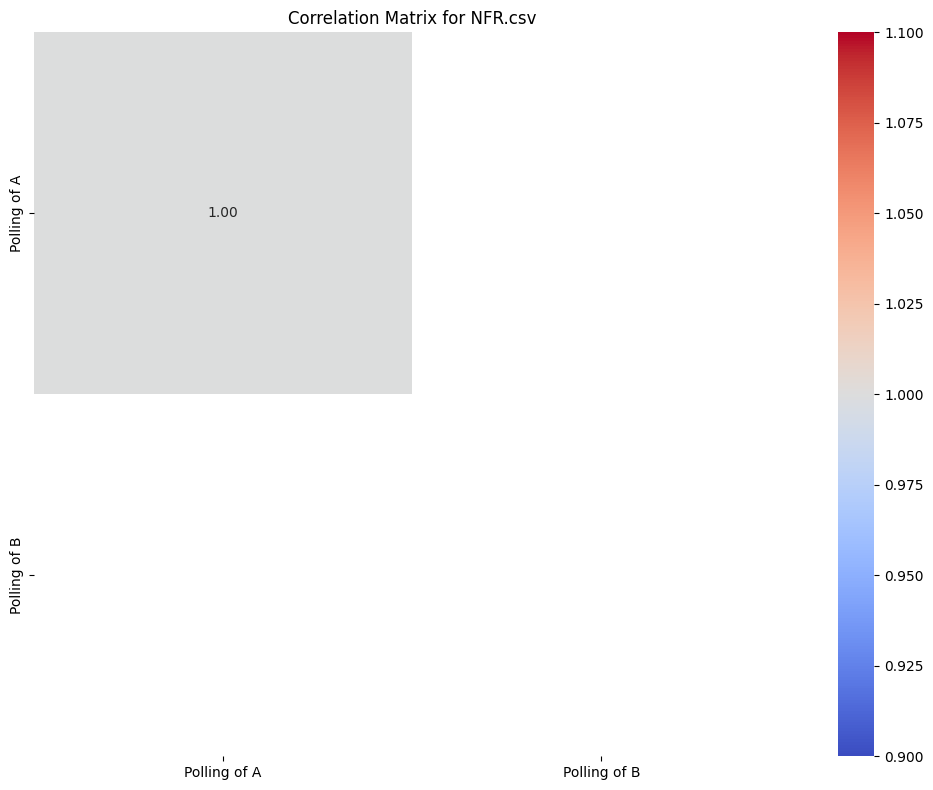

/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


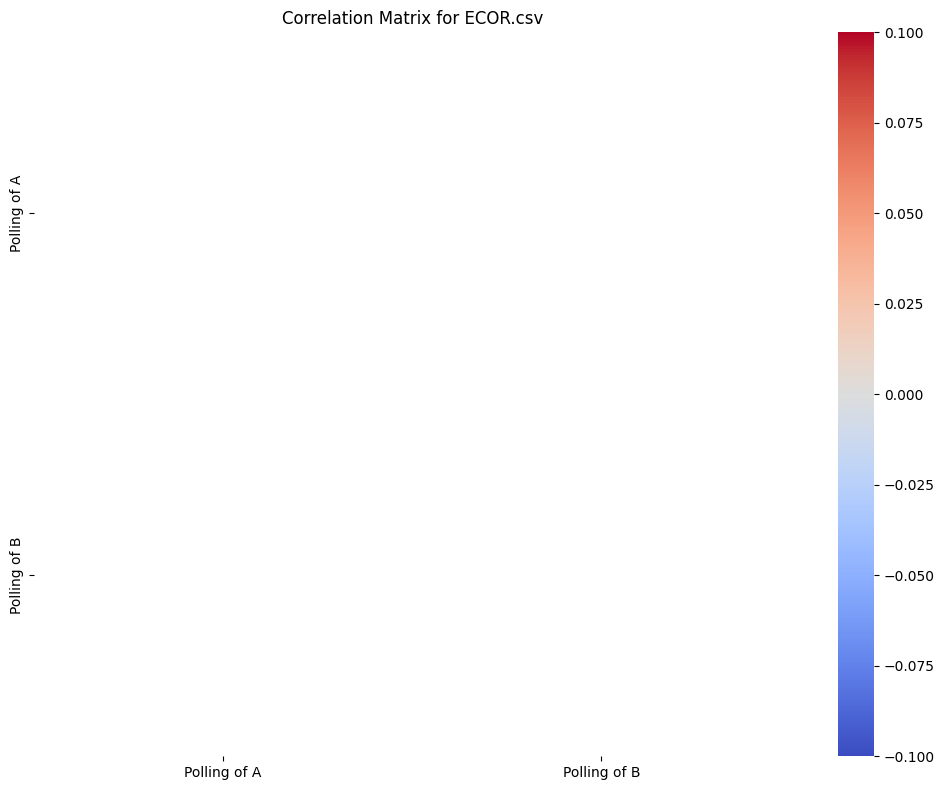

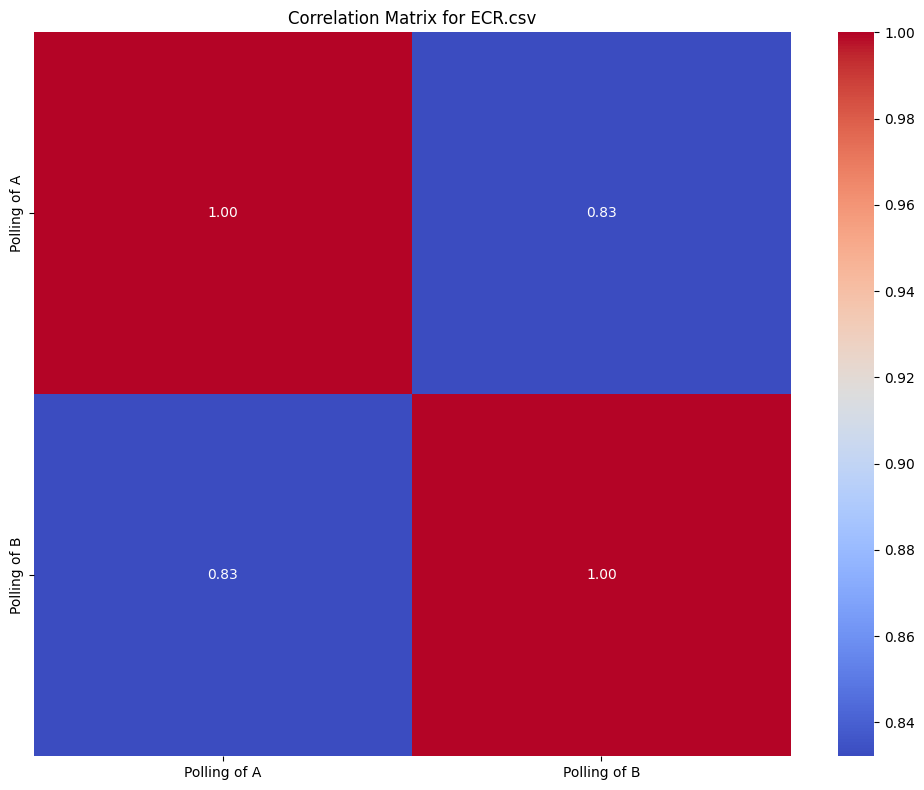

/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


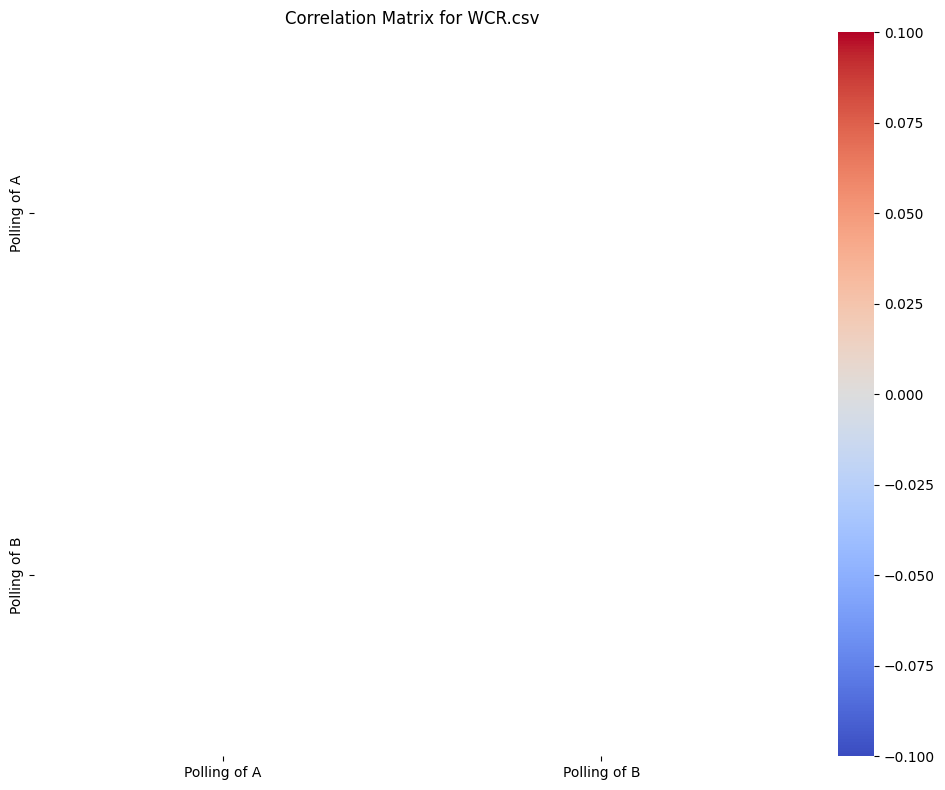

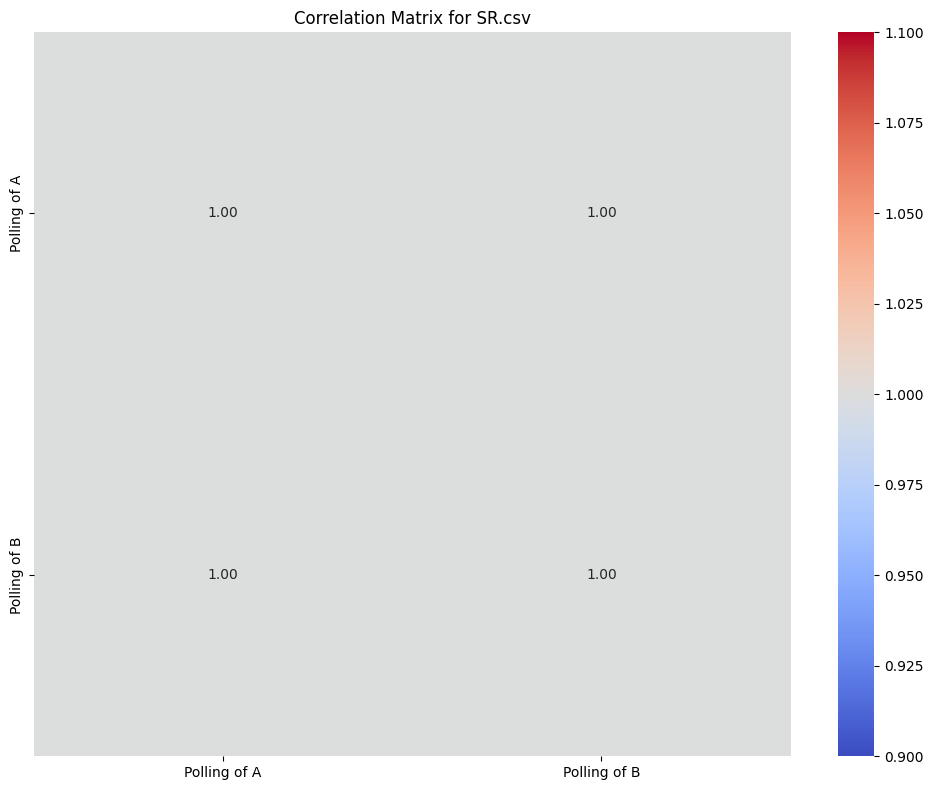

/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


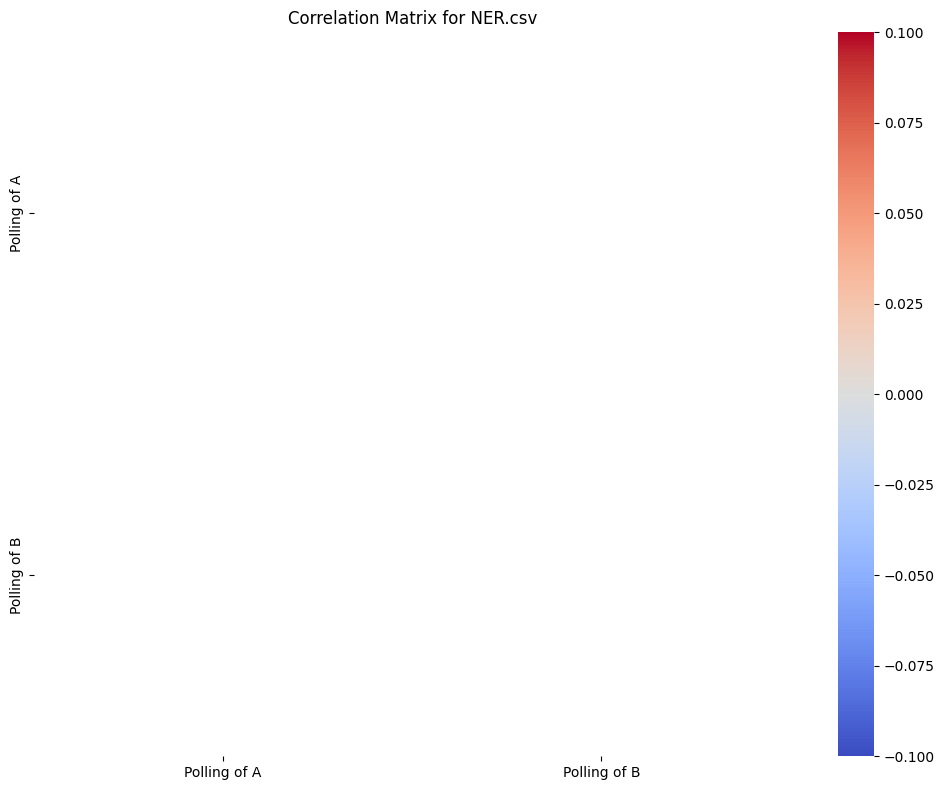

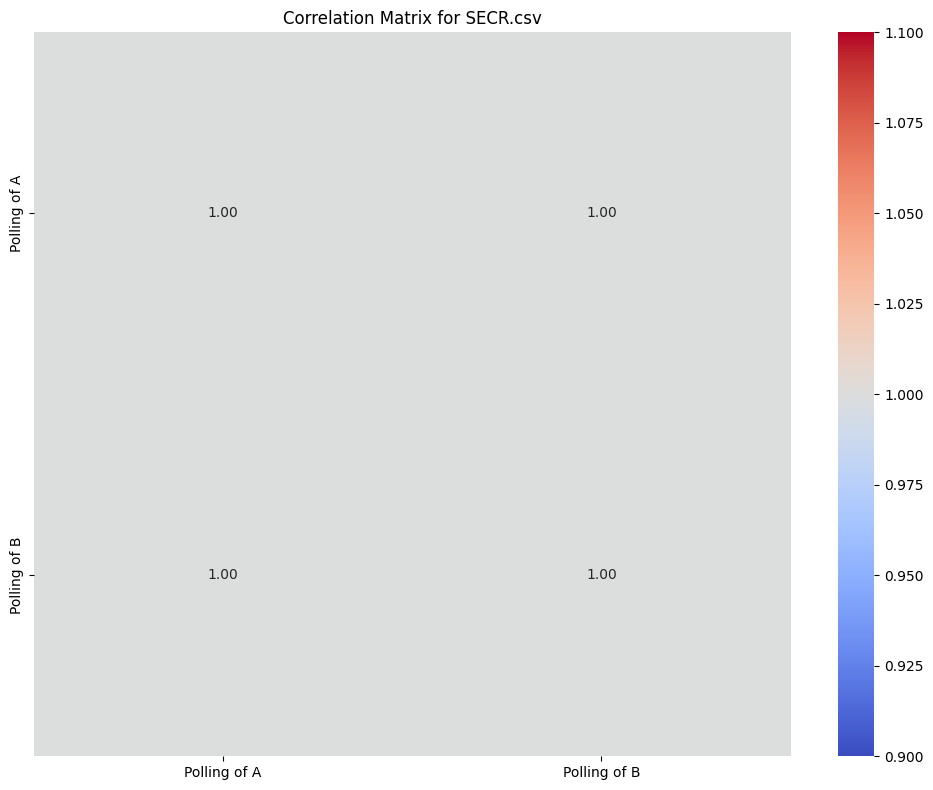

In [12]:
# Compute correlation matrices for each dataset
correlations = {fname: df[common_cols].corr() for fname, df in data.items()}

# Plot heatmaps for correlation matrices
import seaborn as sns

for fname, corr_matrix in correlations.items():
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f"Correlation Matrix for {fname}")
    plt.tight_layout()
    plt.show()

In [13]:
# Compute summary statistics for each dataset
summary_stats = {fname: df[common_cols].describe() for fname, df in data.items()}

# Print summary statistics
for fname, stats in summary_stats.items():
    print(f"Summary Statistics for {fname}:\n")
    print(stats)
    print("\n")

Summary Statistics for WR.csv:

        Polling of A  Polling of B
count  124253.000000       73259.0
mean       81.508696         100.0
std        33.725141           0.0
min        20.000000         100.0
25%       100.000000         100.0
50%       100.000000         100.0
75%       100.000000         100.0
max       100.000000         100.0


Summary Statistics for NR.csv:

       Polling of A  Polling of B
count       52334.0       45896.0
mean           20.0          20.0
std             0.0           0.0
min            20.0          20.0
25%            20.0          20.0
50%            20.0          20.0
75%            20.0          20.0
max            20.0          20.0


Summary Statistics for NCR.csv:

       Polling of A  Polling of B
count       10270.0       10270.0
mean          100.0         100.0
std             0.0           0.0
min           100.0         100.0
25%           100.0         100.0
50%           100.0         100.0
75%           100.0         100.0
max   

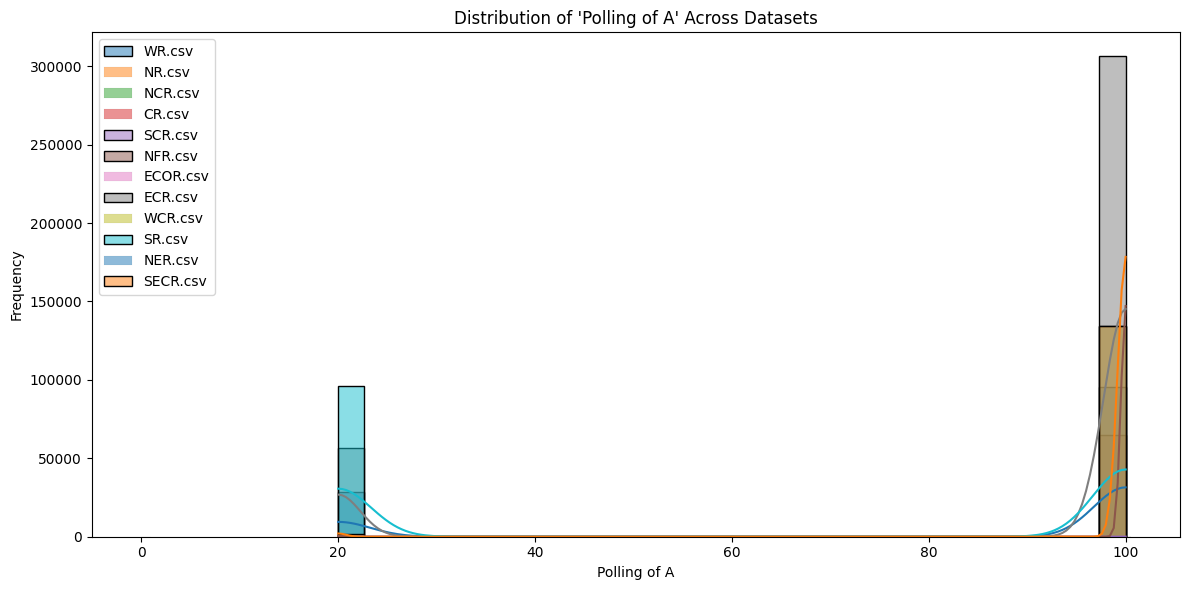

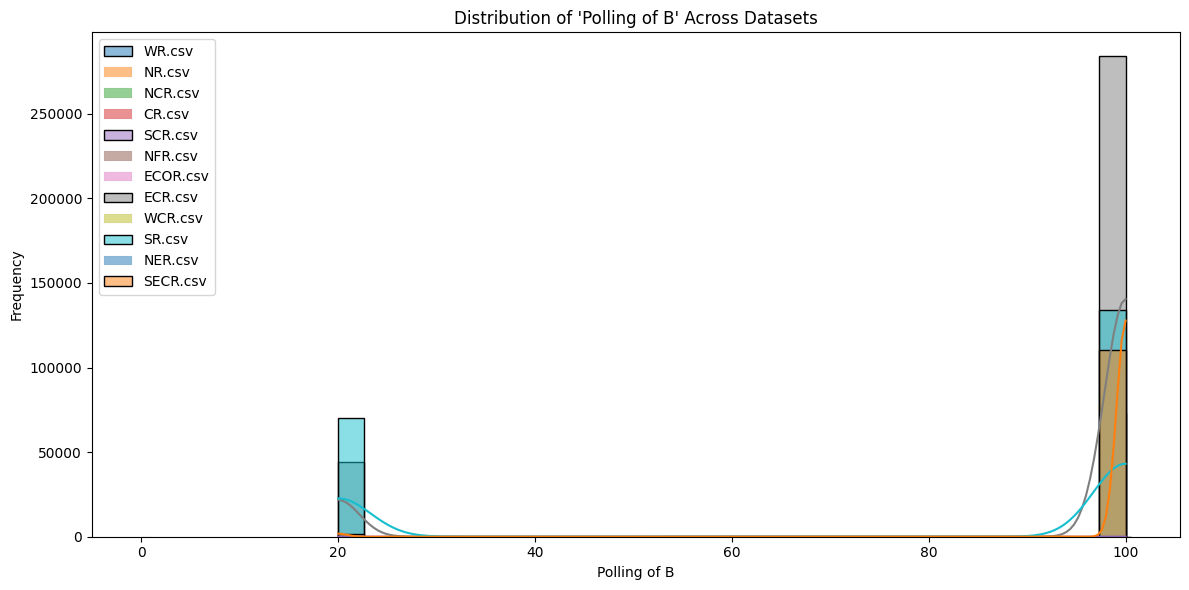

In [14]:
# Plot histograms for each numeric column across datasets
for col in common_cols:
    plt.figure(figsize=(12, 6))
    for fname, df in data.items():
        sns.histplot(df[col], kde=True, label=fname, bins=30, alpha=0.5)
    plt.title(f"Distribution of '{col}' Across Datasets")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

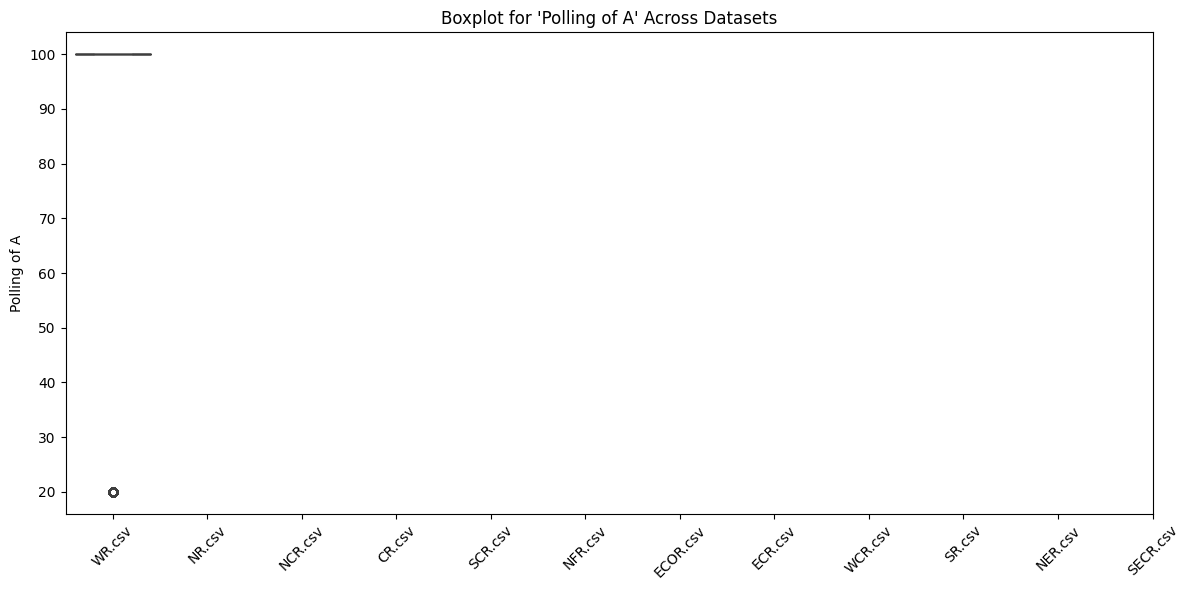

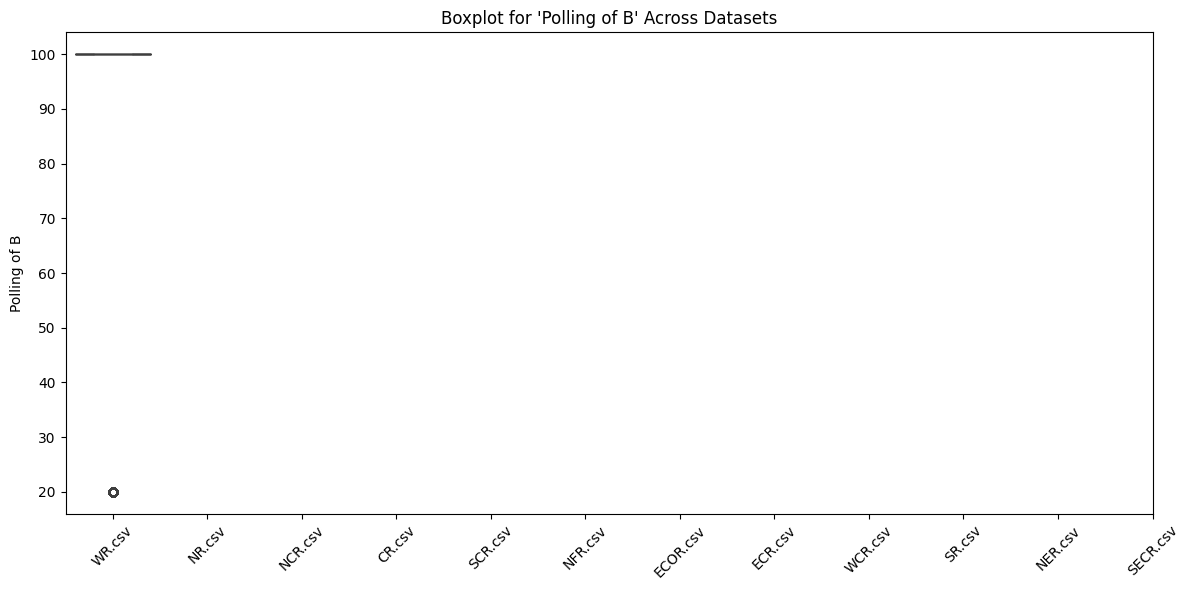

In [15]:
# Plot boxplots for each numeric column across datasets
for col in common_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=[df[col].dropna() for df in data.values()], notch=True)
    plt.xticks(ticks=range(len(data)), labels=data.keys(), rotation=45)
    plt.title(f"Boxplot for '{col}' Across Datasets")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

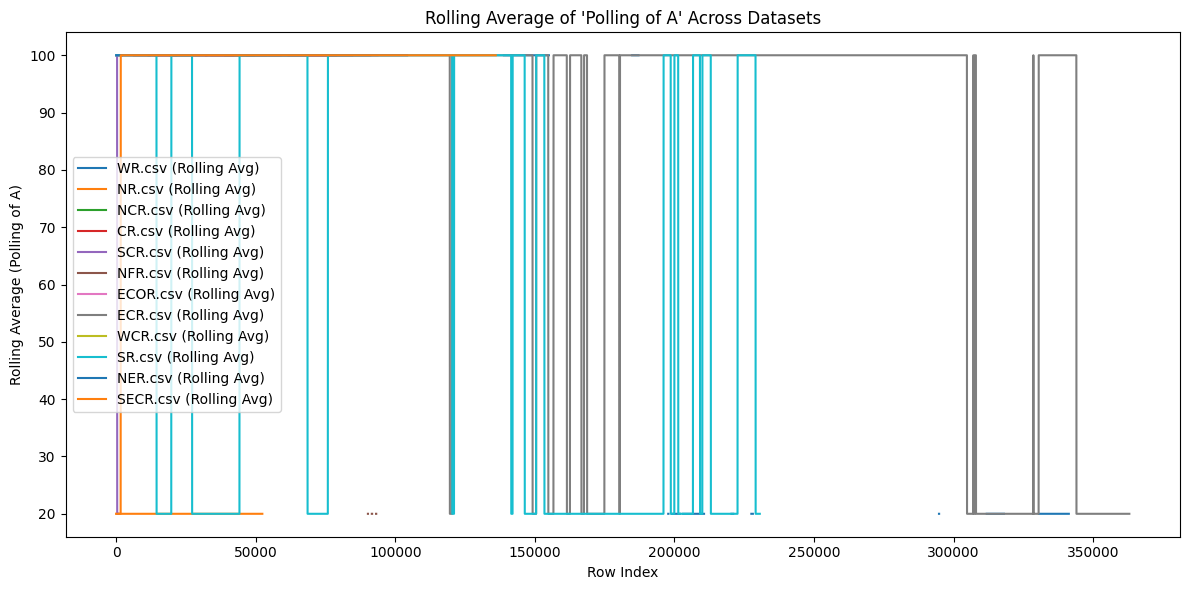

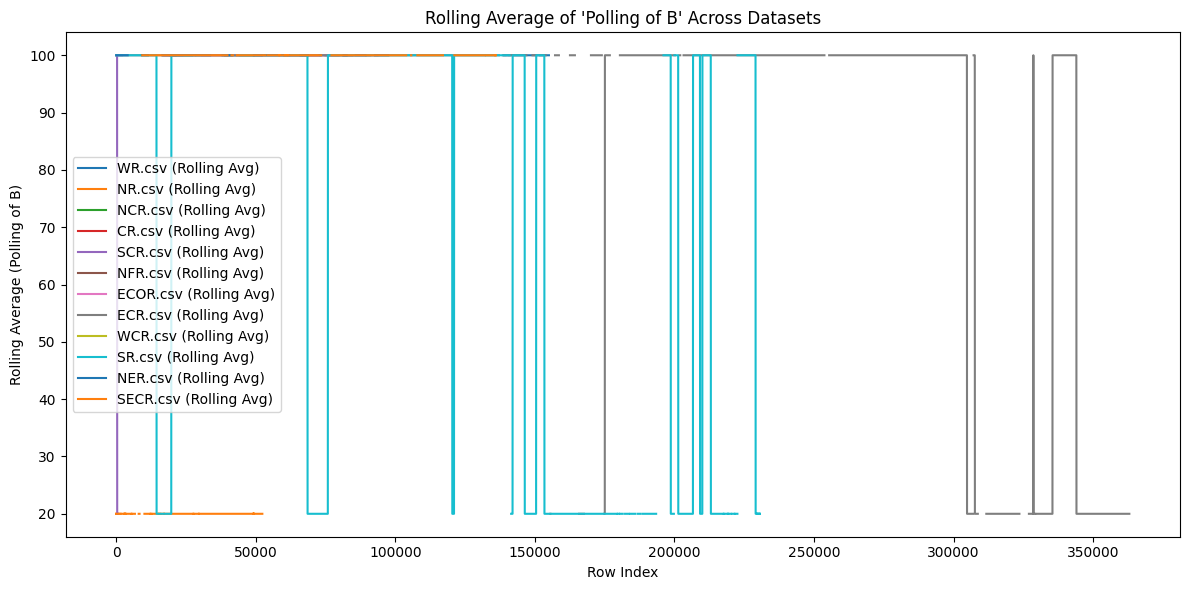

In [16]:
# Plot rolling averages for each numeric column across datasets
window_size = 5  # Adjust rolling window size as needed
for col in common_cols:
    plt.figure(figsize=(12, 6))
    for fname, df in data.items():
        rolling_avg = df[col].rolling(window=window_size).mean()
        plt.plot(rolling_avg, label=f"{fname} (Rolling Avg)")
    plt.title(f"Rolling Average of '{col}' Across Datasets")
    plt.xlabel("Row Index")
    plt.ylabel(f"Rolling Average ({col})")
    plt.legend()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_219016/2590535971.py:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


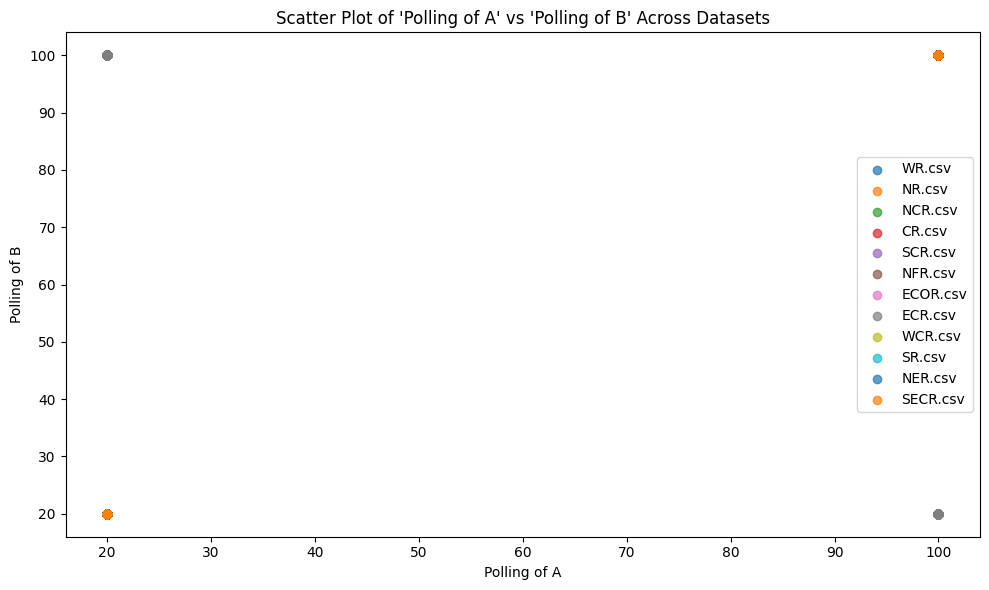

: 

In [ ]:
# Scatter plot for pairwise column comparison
col1, col2 = common_cols[:2]  # Choose two columns to compare
plt.figure(figsize=(10, 6))
for fname, df in data.items():
    plt.scatter(df[col1], df[col2], label=fname, alpha=0.7)
plt.title(f"Scatter Plot of '{col1}' vs '{col2}' Across Datasets")
plt.xlabel(col1)
plt.ylabel(col2)
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
# Assuming the first column is a time column
time_col = data[file_names[0]].columns[0]  # Adjust as needed
for col in common_cols:
    plt.figure(figsize=(12, 6))
    for fname, df in data.items():
        plt.plot(df[time_col], df[col], label=fname)
    plt.title(f"Time-Series Analysis of '{col}'")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

NameError: name 'data' is not defined

/tmp/ipykernel_551165/1446095294.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/home/understressengineer/programming/env_hack/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


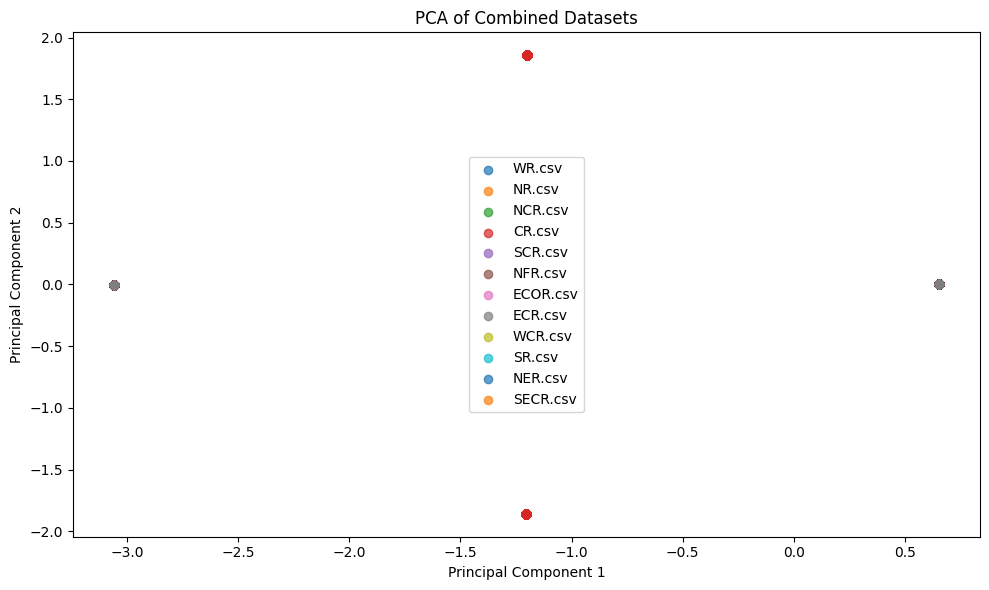

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Combine all datasets for PCA
combined_data = pd.concat([df[common_cols] for df in data.values()], axis=0)
scaled_data = StandardScaler().fit_transform(combined_data.dropna())

# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Plot PCA results
plt.figure(figsize=(10, 6))
start_idx = 0
for fname, df in data.items():
    end_idx = start_idx + len(df)
    plt.scatter(pca_result[start_idx:end_idx, 0], pca_result[start_idx:end_idx, 1], label=fname, alpha=0.7)
    start_idx = end_idx
plt.title("PCA of Combined Datasets")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()